# Tutorial 1 — Codecs: tokenizing each modality

---
### The big picture: why tokenize at all?

Transformers were originally designed to work with **sequences of tokens**. In a language model, a sentence is first converted into a list of token IDs. Each token ID is just an integer, such as `17`, `842`, or `30521`, which points to one entry in a vocabulary. The transformer does not directly read raw text characters or words. Instead, it receives these token IDs after they have been converted into learned embedding vectors.

In Tutorials 1 and 2, our goal is to build a single transformer model, **Gal4M**, that can learn from multiple modalities and form a unified representation of a **galaxy**.
But a galaxy is not naturally a sequence of token IDs. In our dataset, each galaxy is represented by several different modalities: an image, one or more physical curves, and some floating-point scalar properties. These are continuous arrays of numbers, not discrete tokens.

So before we can feed these modalities into a transformer, we need to translate each modality into a form that looks more like language tokens. In other words, we want to represent each modality as **a short sequence of integers chosen from a fixed vocabulary**.

This translation step is called **tokenization**. The model that performs this translation is called a **codec**, short for coder-decoder. The encoder part maps the original data, such as an image or a curve, into discrete token IDs. The decoder part tries to reconstruct the original data from those token IDs. If the reconstruction is good, then the token sequence has preserved the important information in the original modality.

A useful tokenization should have two main properties.

* **Discrete**. Each token should be an integer from a finite vocabulary, for example from `0` to `1023`. This makes the prediction problem similar to language modeling. Instead of predicting a floating-point image pixel directly, the transformer can predict which token ID should appear at each position. This becomes a **classification problem** over the vocabulary.

* **Short**. The token sequence should be much shorter than the original raw data. For example, an image with shape `(8, 128, 128)` contains 131,072 floating-point numbers. If the codec represents this image using 1024 token IDs, then the transformer only needs to model a much shorter sequence. This compression is important because transformer attention becomes more expensive as the sequence length grows. Short token sequences make it practical to combine several modalities into one joint multimodal model.

This is the same general idea used in models such as **VQ-VAE** and **VQ-GAN**, where images are first converted into discrete visual tokens. It is also closely related to multimodal “any-to-any” models such as **4M** and **AION**. The recipe is simple in spirit: first tokenize each modality with its own codec, then concatenate the resulting token sequences, and finally train one transformer to model the combined multimodal token stream.

In this tutorial, we will build these modality-specific codecs first. Later, in Tutorial 2, we will use their tokenized outputs as the input and prediction targets for a multimodal transformer.

---
### What a codec is:

A **codec** maps one modality to a short sequence of discrete tokens, and can also map those tokens back to a reconstruction of the original modality. In this tutorial, every codec exposes the same two main methods through `aion.codecs.base.Codec`:

```python
codec.encode(modality) -> LongTensor[B, n_tokens]
codec.decode(tokens)   -> modality
```

Conceptually, the codec has two parts: an encoder–decoder that works in a continuous latent space, and a quantizer that turns continuous latent vectors into discrete token IDs.

```text
Encode
------
raw modality ──► _encode ──► z_e ∈ R^{B × n_tokens × d_code} ──► quantizer.encode ──► tokens ∈ {0, ..., K-1}^{B × n_tokens}


Decode
------
tokens ∈ {0, ..., K-1}^{B × n_tokens} ──► quantizer.decode ──► z_q ∈ R^{B × n_tokens × d_code} ──► _decode ──► reconstruction
```

The two halves do different jobs. The `_encode` and `_decode` functions form the modality-specific reconstruction model. For example, an image codec uses an image encoder and image decoder, while a scalar codec or curve codec may use a simpler architecture.

The **quantizer** is the part that makes the representation discrete. It compares each continuous latent vector from `_encode` with a learned codebook containing `K` vectors, where `K` is the **vocabulary size** of the codebook. For each latent vector, the quantizer chooses the closest codebook entry and stores only that entry’s integer index (an integer in the range `0, ..., K-1`). These integer indices are the **tokens** that will later be passed to the transformer.


When we decode, we do the reverse lookup: each token ID is replaced by its corresponding codebook vector, and `_decode` turns those vectors back into an approximate reconstruction of the original modality.

So the codec is not just compressing the data. It is translating each modality into the transformer's native format: a short sequence of integer token IDs.


---
### Choosing a codec family for each modality

Different modalities have different structures, so Gal4M does not use the same codec for everything. The goal is to choose a codec that matches the shape and complexity of each data type.

| Codec family                  | Used for                       | Why this choice makes sense                                                                                                                                                        |
| ----------------------------- | ------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Scalar quantile quantizer** | 8 physical scalars             | Each scalar is a single number, so it can be converted directly into one ordinal token. No neural network is needed.                                                               |
| **1-D ConvNeXt VQ-AE + LFQ quantizer**  | SFH and gas/DM radial profiles | These modalities are smooth one-dimensional curves, so a 1-D encoder can compress each curve into a short sequence of discrete tokens.                                             |
| **2-D MagVit VQ-AE + FSQ quantizer**    | Galaxy images                  | Images have two-dimensional spatial structure, so a convolutional image codec is needed. The image codec produces many tokens, arranged on a 2-D grid, for example (32 X 32). |

We introduce the codecs in this order, from simplest to most structured. Scalars are the easiest because each value can be quantized directly. One-dimensional curves require a neural codec, but their structure is still relatively simple. Images are the most complex modality here, because the codec must preserve spatial morphology and local image features.

In this tutorial, we train the codecs on the **multi-redshift** dataset, which contains **19,118 galaxies across five snapshots** from (z = 0.0) to (z = 0.4). We validate them on a held-out set of **500 galaxies**, with **100 galaxies from each redshift**.


---
## How this notebook is meant to be run

This notebook can be run in two modes.

The scalar codec is simple and does not need training, but the neural codecs for SFH, gas/DM profiles, and galaxy images do need training. In particular, the image codec is relatively expensive and should be trained on a GPU.
To make the notebook easy to use, we control training with the `GAL4M_TRAIN` environment variable. The TRAIN flag below simply reads this environment variable.

1. **Load pass (default).** Run the notebook normally. The training cells are
   **skipped**; each codec is **loaded** from `checkpoints/codecs/` and we
   **demonstrate its reconstruction** on the held-out, multi-redshift validation
   set. This runs on a laptop.
2. **Train pass (GPU)**. To train the neural codecs yourself, set GAL4M_TRAIN=1 before running the notebook. 
   In this mode, the training cells are executed inline using the same procedure that produced the published checkpoints: python -m sim.train_codecs 
   over all five snapshots, about 3 h on one V100, keeping the best validation checkpoint for each codec.

The `TRAIN` flag below reads `GAL4M_TRAIN`.

**One normalization, shared everywhere.** The galaxy-image normalization is fixed: `img_norm.json` was computed once from a fair sample of training images, then reused for training, validation, and downstream tokenization. We do **not** recompute it per batch or per split. This keeps all galaxy images on the same scale, so the codec sees consistent, in-distribution inputs.

> **Data & checkpoints.** This notebook downloads data and pre-trained checkpoints from the Hugging Face Hub repo
> [`yueyingn/multimodal-galaxy-tutorial`](https://huggingface.co/yueyingn/multimodal-galaxy-tutorial). Files download automatically on first use into `data/` and `checkpoints/`. To fetch everything up front, run:
>
> ```python
> from sim.hub import download_data, download_checkpoints
> download_data(); download_checkpoints()
> ```

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
%matplotlib inline

from sim.hub import (
    DATA_DIR,
    CHECKPOINTS_DIR,
    data_path,
    checkpoint_path,
)

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# TRAIN pass (GPU) vs. LOAD pass (default). 
# os.environ["GAL4M_TRAIN"] = "1" # (GPU)
# os.environ["GAL4M_TRAIN"] = "0" # (default)

TRAIN = os.environ.get("GAL4M_TRAIN", "0") == "1"

# Data paths
TRAIN_FILES = [
    os.path.join(DATA_DIR, f"Snap{s}.npz")
    for s in (72, 78, 84, 91, 99)
]
VAL_FILE = data_path("val.npz")       # 500 held-out galaxies, auto-downloaded if needed
SAVE_DIR = CHECKPOINTS_DIR            # checkpoints/codecs/<modality>/

# Codec settings
VOCAB_SCALAR = 1024                   # scalar vocabulary size
N_TOK = 64                            # number of galaxies tokenized in the final demo

# Fixed train-set image normalization, shared by training, validation, and tokenization.
with open(data_path("img_norm.json")) as f:
    img_norm = json.load(f)

IMG_NORM = {
    "median": img_norm["median"],
    "iqr": img_norm["iqr"],
}

# Hyperparameters for the inline TRAIN pass
EPOCHS_1D = 100
BATCH_1D = 64

EPOCHS_IMG = 60
BATCH_IMG = 8
LR_IMG = 1e-4

print(f"device={DEVICE}   TRAIN={TRAIN}   img_norm={IMG_NORM}")

device=cpu   TRAIN=False   img_norm={'median': 7.5859375, 'iqr': 4.05078125}


In [2]:
from sim.dataset import GalaxyDataset
from sim.modalities import (
    SIM_BANDS, SimGalaxyImage,
    SimSFH, SimGasProfile, SimDMProfile,
    SimSFR, SimMstar, SimMhalo, SimR200, SimMbh, SimEgyRM, SimRMpow, SimRedshift,
)

# Held-out validation set:
# 500 galaxies total, 100 per redshift from z=0.0 to z=0.4.
# Use the same fixed image normalization as training so validation images remain in-distribution.
val_ds = GalaxyDataset([VAL_FILE], normalize_images=True, img_norm=IMG_NORM)
zred = np.round(1.0 / val_ds.scale_factor.numpy() - 1.0, 2)

# one representative galaxy per redshift for the reconstruction panels
reps = [int(np.where(zred == zz)[0][0]) for zz in sorted(set(zred.tolist()))]

if TRAIN:
    # The full multi-redshift training set (19,118 galaxies across 5 snapshots).
    train_ds = GalaxyDataset(TRAIN_FILES, normalize_images=True, img_norm=IMG_NORM)
    print(f"train={len(train_ds)}  val={len(val_ds)}",f"redshifts={[round(float(z), 2) for z in sorted(set(zred.tolist()))]}")
else:
    train_ds = None
    print(
    f"LOAD pass: val={len(val_ds)} galaxies,", f"redshifts={[round(float(z), 2) for z in sorted(set(zred.tolist()))]}")

# Fixed axes shared by all galaxies.
# These are required by the 1-D codecs during decoding.
time_grid   = val_ds.sfh[0, 0, :].clone()
radius_grid = val_ds.gas_prof[0, 0, :].clone()

LOAD pass: val=500 galaxies, redshifts=[0.0, 0.1, 0.2, 0.3, 0.4]


## Training and loading helpers

Before introducing the individual modality codecs, we first define a small set of helper functions that they share. These include a **checkpoint loader**, which restores the best saved model, and a general **1D training loop**, which is used for the SFH and radial-profile codecs. The larger 2D image trainer is defined separately below.

All trainers follow the same validation-and-checkpointing logic. At the end of each epoch, the model is evaluated using reconstruction MSE on a **held-out multi-redshift validation set**. A checkpoint is saved only when the validation loss improves, so the model stored on disk is the **best validation model**, rather than simply the final model from the last epoch.

Each trainer takes the training tensor `Xtr` and validation tensor `Xva` explicitly. In this tutorial, `Xtr` is built from the five training snapshots, while `Xva` comes from `val.npz`.

In [3]:
def load_codec(codec, modality):
    """Load the best saved checkpoint for one modality codec."""
    path = checkpoint_path(f"codecs/{modality.name}/pytorch_model.bin")
    state_dict = torch.load(path, map_location=DEVICE, weights_only=True)

    codec.load_state_dict(state_dict)
    return codec.to(DEVICE).eval()

@torch.no_grad()
def _val_mse_1d(codec, Xva, Mod):
    """Compute validation reconstruction MSE for a 1-D codec."""
    codec.eval()

    # Encode the validation data, quantize the latent vectors, and decode them back.
    z = codec._encode(Mod(value=Xva))
    z_q, _, _ = codec.quantizer(z)
    xh = codec._decode(z_q)
    
    # The 1-D codecs reconstruct only the physical channel stored at index 1.
    return F.mse_loss(xh.value[:, 1:2, :], Xva[:, 1:2, :]).item()


def train_1d_codec(codec, Xtr, Xva, Mod, modality, epochs, title):
    """
    Train a 1-D LFQ codec and save the checkpoint with the best validation MSE.

    Parameters
    ----------
    codec: The codec model to train.
    Xtr: Training tensor.
    Xva: Validation tensor.
    Mod: Modality wrapper class used by this codec.
    modality: Modality object used to name the saved checkpoint.
    epochs: Number of training epochs.
    title: Short name used in progress messages.

    Returns
    -------
    hist:
        List of validation MSE values, one per epoch.
    """
    codec = codec.to(DEVICE)
    Xtr = Xtr.to(DEVICE)
    Xva = Xva.to(DEVICE)

    opt = AdamW(codec.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)

    best = float("inf")
    hist = []

    for ep in range(epochs):
        codec.train()

        # Shuffle the training set each epoch.
        perm = torch.randperm(len(Xtr), device=DEVICE)

        for i in range(0, len(Xtr), BATCH_1D):
            xb = Xtr[perm[i:i + BATCH_1D]]

            # Encode -> quantize -> decode.
            z = codec._encode(Mod(value=xb))
            z_q, lfq_loss, _ = codec.quantizer(z)
            xh = codec._decode(z_q)

            # Reconstruction loss plus the LFQ auxiliary loss.
            recon_loss = F.mse_loss(xh.value[:, 1:2, :], xb[:, 1:2, :])
            loss = recon_loss + 0.1 * lfq_loss

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(codec.parameters(), 1.0)
            opt.step()

        sched.step()

        # Evaluate on the held-out validation set and save only if improved.
        vmse = _val_mse_1d(codec, Xva, Mod)
        hist.append(vmse)

        if vmse < best:
            best = vmse
            codec.save_pretrained(SAVE_DIR, modality=modality)

        if ep == 0 or (ep + 1) % 25 == 0:
            print(
                f"  {title} epoch {ep + 1:3d}/{epochs}  "
                f"val MSE={vmse:.4f}  best={best:.4f}"
            )

    print(f"  {title}: best val MSE = {best:.4f}  -> saved")
    return hist

The **2-D image trainer** follows the same basic validation-and-checkpointing logic, with two small differences. First, the validation set is evaluated in batches, because the 8-band images are too large to pass through the encoder all at once. Second, there is no LFQ auxiliary loss: the FSQ quantizer is parameter-free, so the training objective is simply the reconstruction MSE on the `(8, 128, 128)` flux images.

In [4]:
def train_image_codec(codec, Xtr, Xva, modality, epochs, title):
    """
    Train the 2-D image codec and save the checkpoint with the best validation MSE.

    The image validation set is evaluated in batches because the full 8-band image
    tensor can be too large to process at once.
    """
    codec = codec.to(DEVICE)

    opt = AdamW(codec.parameters(), lr=LR_IMG, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)

    best = float("inf")
    hist = []

    for ep in range(epochs):
        codec.train()

        # Shuffle the training images each epoch.
        perm = torch.randperm(len(Xtr))

        for i in range(0, len(perm), BATCH_IMG):
            xb = Xtr[perm[i:i + BATCH_IMG]].to(DEVICE)

            # Encode -> quantize -> decode.
            z = codec._encode(SimGalaxyImage(flux=xb, bands=SIM_BANDS))
            z_q, _, _ = codec.quantizer(z)
            xh = codec._decode(z_q)

            # FSQ is parameter-free, so we only use reconstruction MSE.
            loss = F.mse_loss(xh.flux, xb)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(codec.parameters(), 1.0)
            opt.step()

        sched.step()

        # Evaluate reconstruction MSE on the validation set in batches.
        codec.eval()
        val_loss = 0.0
        n_batches = 0

        with torch.no_grad():
            for i in range(0, len(Xva), BATCH_IMG):
                xb = Xva[i:i + BATCH_IMG].to(DEVICE)

                z = codec._encode(SimGalaxyImage(flux=xb, bands=SIM_BANDS))
                z_q, _, _ = codec.quantizer(z)
                xh = codec._decode(z_q)

                val_loss += F.mse_loss(xh.flux, xb).item()
                n_batches += 1

        vmse = val_loss / n_batches
        hist.append(vmse)

        # Keep only the checkpoint with the best validation reconstruction.
        if vmse < best:
            best = vmse
            codec.save_pretrained(SAVE_DIR, modality=modality)

        print(
            f"  {title} epoch {ep + 1:3d}/{epochs}  "
            f"val MSE={vmse:.4f}  best={best:.4f}"
        )

    print(f"  {title}: best val MSE = {best:.4f}  -> saved")
    return hist

---
---
## Family 1 — Scalars: a quantile codec with no neural network

We start with the simplest modality: **scalar physical properties**. A scalar, such as `log M_halo`, is just one number per galaxy. Instead of training a neural autoencoder, we can tokenize this number directly.
For each scalar, we use a **quantile quantizer** implemented by `ScalarReservoirQuantizer`. Its job is to convert one continuous value into one integer token.
The idea is simple: we estimate where a value lies in the empirical distribution of the training data, then use that percentile to assign a token.

### How it works

1. **Calibrate** -- We stream the scalar values from the training set through a reservoir sampler. This gives us an approximate empirical cumulative distribution function, or CDF. The CDF tells us, for any value, what fraction of training examples are smaller than or equal to it.

2. **Encode** -- To encode a scalar value, we compute its CDF value and map it to an integer token:
   ```python
   token = round(CDF(value) * (vocab - 1))```
   This creates approximately equal-probability bins. In other words, each token is used for roughly the same number of training examples.
   This is useful because the quantizer automatically spends more resolution in dense regions of the data distribution, where many galaxies live, and less resolution in sparse tails.

3. **Decode** -- To decode a token, we map it back to a representative scalar value for that quantile bin.
   The reconstruction is not exact, because many nearby values may fall into the same bin. But for scalar quantities, this simple quantile-based reconstruction is usually sufficient.

### Ordinal tokens

Because the bins are ordered by scalar value, neighboring tokens correspond to neighboring scalar values. For example, token 100 represents a smaller value than token 700.
This means the scalar tokens are **ordinal**. That is why `sim/modality_info.py` marks scalar modalities with `is_ordinal = True`.
This is different from image tokens in a vector-quantized codebook, where token IDs are just arbitrary codebook indices. For scalar quantile tokens, the index itself carries ordering information.

### Handling floors and non-detections

Some scalar fields have a special low-value floor. For example, quenched galaxies may have extremely low or effectively undetected SFR. 
If we naively quantized those values, many tokens could be wasted representing an artificial pile-up at the floor.

To avoid this, the codec factory can re-base the floor before calibration. For example:

```python
make_sfr_codec(..., floor=-4.0)
make_egyRM_codec(..., floor=-2.0)
```
This keeps the token resolution focused on the physically meaningful range of the data.

### What we use in this tutorial

On the TRAIN pass, we calibrate all 8 scalar (sfr, mstar, mhalo, r200, mbh, egyRM, RMpow, redshift) using the training set.
Each scalar uses `codebook_size = 1024`.
After calibration, we save the scalar codec checkpoints. 
On the LOAD pass, we simply load the saved checkpoints instead of recalibrating them.

In [5]:
from sim.codecs.scalars import (
    make_sfr_codec, make_mstar_codec, make_mhalo_codec, make_r200_codec,
    make_mbh_codec, make_egyRM_codec, make_RMpow_codec, make_redshift_codec,
)

# Each scalar modality uses the same workflow:
#   1. create a quantile codec
#   2. calibrate it on the training split, or load a saved checkpoint
#   3. store it in scalar_codecs
#
# The tuple entries are:
#   codec factory, modality wrapper, dataset attribute, plot label
scalar_specs = {
    "sim_sfr":      (make_sfr_codec,      SimSFR,      "sfr0",         r"$\log$ SFR"),
    "sim_mstar":    (make_mstar_codec,    SimMstar,    "m4s",          r"$\log M_\star$"),
    "sim_mhalo":    (make_mhalo_codec,    SimMhalo,    "mhs",          r"$\log M_{\rm halo}$"),
    "sim_r200":     (make_r200_codec,     SimR200,     "r200",         r"$\log r_{200}$"),
    "sim_mbh":      (make_mbh_codec,      SimMbh,      "mbh",          r"$\log M_{\rm BH}$"),
    "sim_egyRM":    (make_egyRM_codec,    SimEgyRM,    "egyRM",        "egyRM"),
    "sim_RMpow":    (make_RMpow_codec,    SimRMpow,    "RMpow",        "RMpow"),
    "sim_redshift": (make_redshift_codec, SimRedshift, "scale_factor", "scale factor"),
}

scalar_codecs = {}

for name, (make_codec, Modality, attr, label) in scalar_specs.items():
    # Create one scalar codec with a fixed vocabulary size.
    # For scalars, this is a quantile/CDF codec, not a neural autoencoder.
    codec = make_codec(VOCAB_SCALAR)

    if TRAIN:
        # Calibrate the empirical CDF using only the training split.
        values = getattr(train_ds, attr)
        codec.calibrate(values)

        # Save the calibrated quantile bins so the same tokenizer can be reused later.
        codec.save_pretrained(SAVE_DIR, modality=codec.modality)

    else:
        # Load the saved scalar codec from disk.
        ckpt_path = os.path.join(SAVE_DIR,"codecs",name,"pytorch_model.bin",)
        state_dict = torch.load(ckpt_path,map_location="cpu",weights_only=True,)
        codec.load_state_dict(state_dict)

    scalar_codecs[name] = codec

status = "calibrated and saved" if TRAIN else "loaded"
print(f"{status} scalar codecs: {list(scalar_codecs)}")

/home/yueyingn/.conda/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded scalar codecs: ['sim_sfr', 'sim_mstar', 'sim_mhalo', 'sim_r200', 'sim_mbh', 'sim_egyRM', 'sim_RMpow', 'sim_redshift']


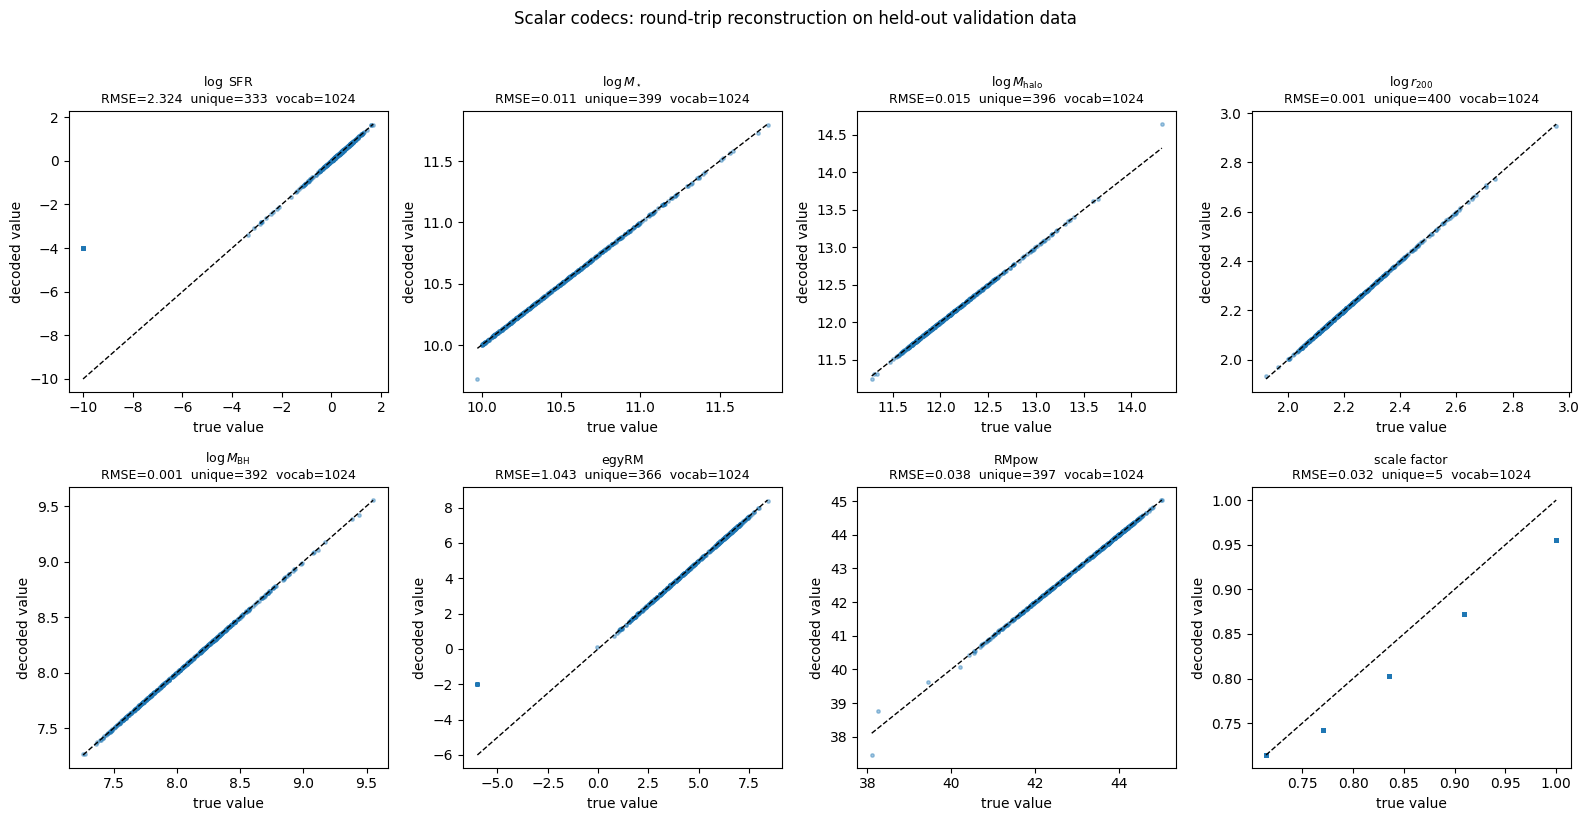

In [6]:
# Check the scalar codecs on the held-out validation split.
#
# For each scalar modality, we do a full round trip:
#
#     true scalar value -> encode -> integer token -> decode -> reconstructed scalar value
#
# Since these are quantile codecs, the decoded value is an approximate representative
# value for the token bin, not an exact reconstruction of the original scalar.

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (name, (make_codec, Modality, attr, label)) in zip(axes.flat, scalar_specs.items()):
    codec = scalar_codecs[name]

    # Get the validation values for this scalar.
    # Shape: [N] -> [N, 1], because the modality wrapper expects a feature dimension.
    true_values = getattr(val_ds, attr).unsqueeze(-1)

    # Encode scalar values into token IDs, then decode the tokens back to scalar values.
    tokens = codec.encode(Modality(value=true_values))
    decoded_values = codec.decode(tokens).value.squeeze(-1)

    true_values = true_values.squeeze(-1)

    # Plot true value versus decoded value.
    ax.scatter(true_values.cpu().numpy(),decoded_values.cpu().numpy(),s=6,alpha=0.4,)

    # Add the ideal y = x line.
    lo = true_values.min().item()
    hi = true_values.max().item()
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)

    # Simple reconstruction diagnostics.
    rmse = torch.sqrt(torch.mean((true_values - decoded_values) ** 2)).item()
    n_unique_tokens = torch.unique(tokens).numel()
    vocab_size = codec.quantizer.codebook_size

    ax.set_title(f"{label}\nRMSE={rmse:.3f}  unique={n_unique_tokens}  vocab={vocab_size}",fontsize=9,)
    ax.set_xlabel("true value")
    ax.set_ylabel("decoded value")

fig.suptitle("Scalar codecs: round-trip reconstruction on held-out validation data",y=1.02,)
fig.tight_layout()
plt.show()

---
---
## Family 2 — 1-D sequences: star-formation history

Next we move from single numbers to a short **1-D sequence**: the star-formation history, or SFH. An SFH is a 24-point curve describing how a galaxy’s star-formation rate changes over time. Because it contains temporal structure, we use a small neural codec rather than a simple scalar quantizer.

For this modality, we use a lightweight **1-D ConvNeXt VQ autoencoder**, implemented as `sim.codecs.sfh.SFHCodec`.

```text"
SFH curve -> _encode -> continuous latents -> quantize -> token IDs -> _decode -> reconstructed SFH
```

The codec has three main steps:

1. **Encode**: `ConvNextEncoder1d` uses a **stride-4 stem** to compress the input from 24 timesteps -> 6 latent positions.

2. **Quantize**: A **Lookup-Free Quantizer**, or LFQ, converts each latent position into one integer token. With `lfq_dim = 10`, the vocabulary size is: `2^10 = 1024`. Since the compressed sequence has 6 latent positions, each SFH becomes **6 tokens**.

3. **Decode**: A transposed-convolution decoder upsamples the quantized sequence back from: 6 latent positions -> 24 timesteps.

Only the **SFR values** are encoded. The time grid is fixed for all galaxies, so it is stored as a codec buffer and restored during decoding.

The training loss is `loss = MSE(SFR reconstruction) + 0.1 * LFQ auxiliary loss`.
The MSE term trains the codec to reconstruct the SFH, while the LFQ auxiliary loss helps maintain a useful discrete tokenization. This matches the implementation in `sim.train_codecs.train_sfh_codec`.

In [7]:
from sim.codecs.sfh import SFHCodec

if TRAIN:
    codec = SFHCodec()
    codec.set_time_grid(time_grid)
    sfh_hist = train_1d_codec(codec, train_ds.sfh, val_ds.sfh, SimSFH, SimSFH, EPOCHS_1D, "SFH")
else:
    print("TRAIN=False -> skipping training; loading the saved SFH checkpoint next.")

TRAIN=False -> skipping training; loading the saved SFH checkpoint next.


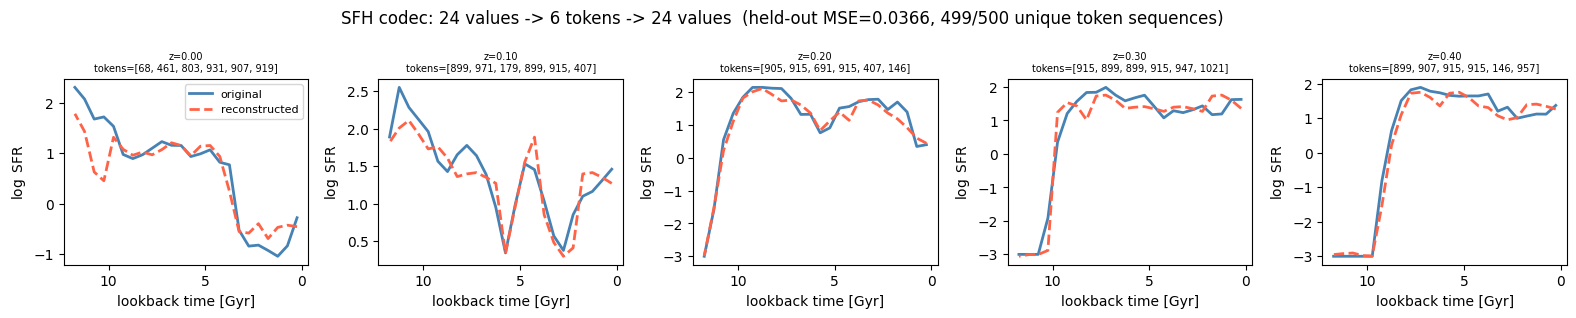

In [8]:
# Load the trained SFH codec and evaluate it on the held-out validation split.
# Round trip: 24-point SFH -> 6 token IDs -> reconstructed 24-point SFH.

sfh_codec = load_codec(SFHCodec(), SimSFH)
sfh_codec.set_time_grid(time_grid.to(DEVICE))
sfh_codec.eval()

sfh = val_ds.sfh.to(DEVICE)
with torch.no_grad():
    tokens = sfh_codec.encode(SimSFH(value=sfh))
    recon = sfh_codec.decode(tokens).value.cpu()

# The SFH tensor stores both the time grid and SFR values; evaluate only the SFR channel.
true_sfr, recon_sfr = val_ds.sfh[:, 1], recon[:, 1]
mse = ((true_sfr - recon_sfr) ** 2).mean().item()
uniq = int(torch.unique(tokens.cpu(), dim=0).shape[0])

fig, axes = plt.subplots(1, len(reps), figsize=(3.2 * len(reps), 3.2), squeeze=False)
for ax, gi in zip(axes.ravel(), reps):
    ax.plot(time_grid, true_sfr[gi], color="steelblue", lw=2, label="original")
    ax.plot(time_grid, recon_sfr[gi], color="tomato", lw=2, ls="--", label="reconstructed")
    ax.invert_xaxis()
    ax.set_xlabel("lookback time [Gyr]")
    ax.set_ylabel(r"$\log$ SFR")
    ax.set_title(f"z={zred[gi]:.2f}\ntokens={tokens[gi].tolist()}", fontsize=7)

axes.ravel()[0].legend(fontsize=8)
fig.suptitle(
    f"SFH codec: 24 values -> 6 tokens -> 24 values  "
    f"(held-out MSE={mse:.4f}, {uniq}/{len(val_ds)} unique token sequences)"
)
fig.tight_layout()
plt.show()

## Family 2 (continued) — Radial density profiles: gas and dark matter

The radial density profiles are 20-point curves. They use the **same basic backbone** as the SFH codec (`GasProfileCodec` / `DMProfileCodec`): a stride-4 stem that reduces the curve to **5 tokens**, followed by an LFQ codebook with vocabulary size 1024.

Gas and dark matter use **separate codecs**, because their profile shapes are physically different. Dark matter profiles are usually centrally concentrated and cusp-like, while gas profiles are more strongly shaped by feedback and can have flatter or more irregular structure.

Two design choices are important here.

* **Standardize the log-density before encoding.** The raw `log10(ρ)` values have a large constant offset, around −6.3, but only modest profile-to-profile variation, about 0.75 dex. Feeding them directly into the encoder can waste codebook capacity and even collapse DM profiles onto nearly identical token sequences. To avoid this, `codec.calibrate(train_profiles)` records the training-set mean and standard deviation; the codec standardizes before encoding and de-standardizes after decoding. This improves reconstruction and gives both gas and DM diverse tokenizations.

* **Use a ConvNeXt block in the decoder.** The radial profiles are smooth but curved. A minimal decoder tends to reconstruct them as overly piecewise-flat curves. Adding one residual ConvNeXt-style block gives the decoder enough local modeling capacity to follow the profile curvature more accurately.

The codec only encodes the density channel. The radial coordinate grid, `r/r200`, is fixed for all galaxies, so it is stored as a buffer and restored during decoding rather than being tokenized.


In [9]:
from sim.codecs.profile import GasProfileCodec, DMProfileCodec

if TRAIN:
    # calibrate() sets the log-density standardization stats (mean/std over the
    # TRAIN split) so the encoder sees a zero-mean, unit-variance signal — this
    # is what lets the LFQ actually use its codebook (see the note above).
    c = GasProfileCodec(); c.set_radius_grid(radius_grid); c.calibrate(train_ds.gas_prof)
    train_1d_codec(c, train_ds.gas_prof, val_ds.gas_prof, SimGasProfile, SimGasProfile, EPOCHS_1D, "gas-prof")
    c = DMProfileCodec(); c.set_radius_grid(radius_grid); c.calibrate(train_ds.dm_prof)
    train_1d_codec(c, train_ds.dm_prof, val_ds.dm_prof, SimDMProfile, SimDMProfile, EPOCHS_1D, "dm-prof")
else:
    print("TRAIN=False -> skipping training; loading the saved profile checkpoints next.")

TRAIN=False -> skipping training; loading the saved profile checkpoints next.


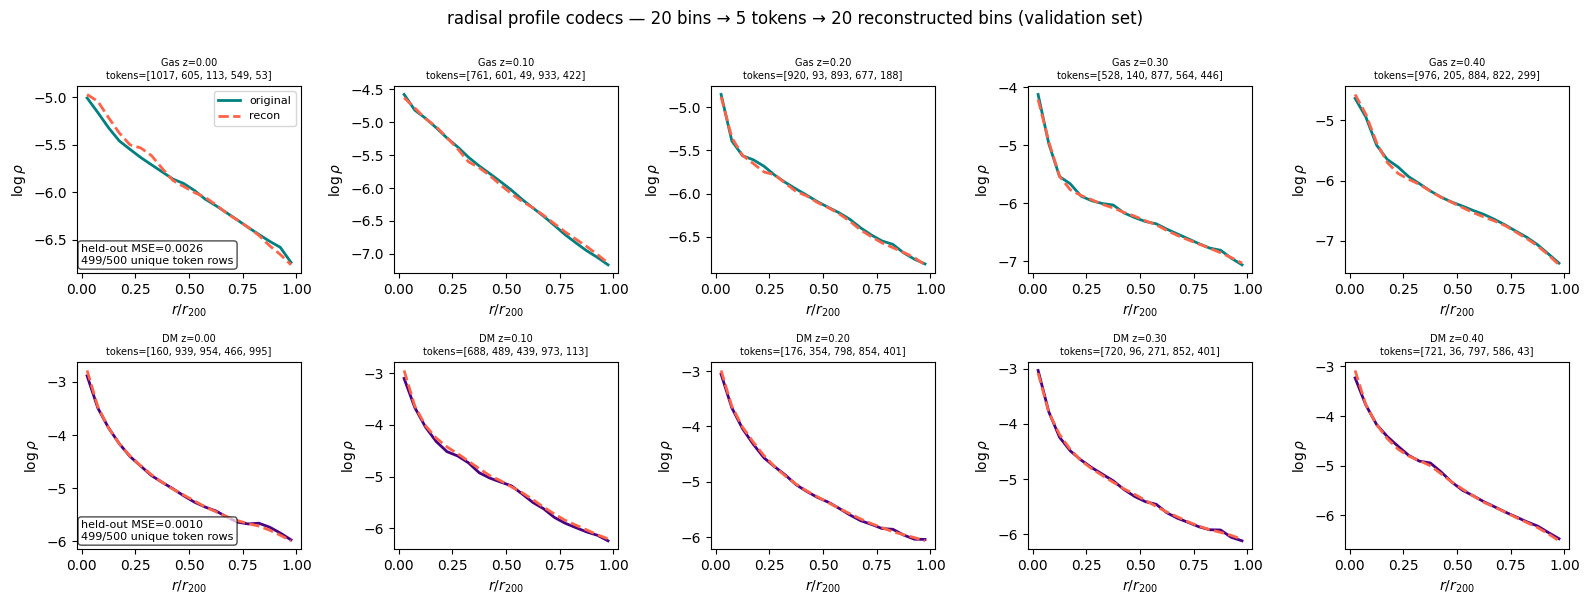

In [13]:
gas_codec = load_codec(GasProfileCodec(), SimGasProfile)
dm_codec  = load_codec(DMProfileCodec(),  SimDMProfile)
for codec in (gas_codec, dm_codec):
    codec.set_radius_grid(radius_grid.to(DEVICE))
    codec.eval()

profile_specs = [
    (gas_codec, "gas_prof", SimGasProfile, "Gas", "teal"),
    (dm_codec,  "dm_prof",  SimDMProfile,  "DM",  "indigo"),
]

n_show = len(reps)
fig, axes = plt.subplots(2, n_show, figsize=(3.2 * n_show, 6), squeeze=False)

for row, (codec, field, Mod, label, color) in enumerate(profile_specs):
    x_val = getattr(val_ds, field).to(DEVICE)

    with torch.no_grad():
        tok = codec.encode(Mod(value=x_val))
        rec = codec.decode(tok).value.cpu()

    true = getattr(val_ds, field)
    mse = ((true[:, 1] - rec[:, 1]) ** 2).mean().item()
    n_unique = torch.unique(tok.cpu(), dim=0).shape[0]

    for col, gi in enumerate(reps):
        ax = axes[row, col]
        ax.plot(radius_grid, true[gi, 1], color=color, lw=2, label="original")
        ax.plot(radius_grid, rec[gi, 1], color="tomato", lw=2, ls="--", label="recon")
        ax.set_xlabel(r"$r/r_{200}$")
        ax.set_ylabel(r"$\log\rho$")
        ax.set_title(f"{label} z={zred[gi]:.2f}\ntokens={tok[gi].cpu().tolist()}", fontsize=7)

        if row == 0 and col == 0:
            ax.legend(fontsize=8)

    axes[row, 0].text(
        0.02, 0.04,
        f"held-out MSE={mse:.4f}\n{n_unique}/{len(val_ds)} unique token rows",
        transform=axes[row, 0].transAxes,
        fontsize=8,
        va="bottom",
        bbox=dict(boxstyle="round", fc="white", alpha=0.7),
    )

fig.suptitle("radisal profile codecs — 20 bins → 5 tokens → 20 reconstructed bins (validation set)", y=1.0)
fig.tight_layout()
plt.show()


## Family 3 — 2D image: galaxy photometric image

The galaxy image contains much more information than a scalar or a 1-D curve, so it uses the heaviest codec in this tutorial: a **MagVit-style convolutional VQ autoencoder** (`sim.codecs.image.SimGalaxyImageCodec`). This modality is the clearest example of the full `encode → quantize → decode` loop:

<div align="center">
  <img src="assets/Image-codec.png" alt="Image codec: encode to tokens, decode back" width="1000">
</div>

Reading the figure from left to right:

* **Encoder**: image → latent grid. 
    The input is an 8-band galaxy image, $x \in \mathbb{R}^{C \times 128 \times 128}$, where $C = 8$ in this tutorial. A convolutional encoder maps it to a lower-resolution grid of latent vectors: $z_e = \mathrm{Encoder}(x)$, with $z_e \in \mathbb{R}^{D \times 32 \times 32}$.
    Here `n_compressions=2`, so the spatial size is downsampled twice: $128 \rightarrow 64 \rightarrow 32$. Therefore each image becomes a $32 \times 32$ latent grid. Each grid cell becomes one token, giving $32 \times 32 = 1024$ tokens per image.

* **Quantizer**: latent grid → token IDs.
    The quantizer turns each continuous latent vector into a discrete token ID. The output is a grid of integer indices, $k \in \{0, \ldots, K-1\}^{32 \times 32}$, where $K$ is the vocabulary size. **These token IDs are what we later pass to the transformer.**
    In a standard VQ-VAE, the quantizer uses a learned codebook $E = [e_1, e_2, \ldots, e_K] \in \mathbb{R}^{K \times D}$, and each latent vector is replaced by its nearest codebook vector.
    In this image codec, the quantizer is instead a **Finite Scalar Quantizer** (**FSQ**). FSQ does not learn a free codebook. It rounds each latent channel to one of a fixed number of levels. Here we use `levels = [5, 5, 5, 5]`, so the implicit vocabulary size is $K = 5^4 = 625$.
    Each spatial cell is assigned one token ID in $\{0, \ldots, 624\}$. Thus this codec produces $32 \times 32 = 1024$ tokens per image, with vocabulary size $K = 625$.
    A useful feature of FSQ is that it avoids the usual learned-codebook collapse problem, because there is no trainable codebook matrix whose entries can become unused.

* **Decoder**: quantized grid → reconstructed image.
    The decoder maps the quantized latent grid back to image space: $\hat{x} = \mathrm{Decoder}(z_q)$, with $\hat{x} \in \mathbb{R}^{C \times 128 \times 128}$. The full codec therefore performs $x \rightarrow z_e \rightarrow k \rightarrow z_q \rightarrow \hat{x}$.
    For one image, this compresses roughly $8 \times 128 \times 128 = 131{,}072$ floating-point values into $32 \times 32 = 1024$ integer token IDs, then decodes them back into an 8-band image.

In short:

* `MagVitAE` encoder with `n_compressions=2` gives a $32 \times 32$ latent grid.
* Each grid cell becomes one image token.
* FSQ with `levels=[5,5,5,5]` gives vocabulary size $K = 5^4 = 625$.
* The decoder reconstructs the original image shape, $(8, 128, 128)$.

Because this codec works on full images, it is the most expensive one to train. The training cell runs for `EPOCHS_IMG` passes on a **GPU**. In the CPU-only load pass, this cell is skipped and the saved checkpoint is loaded instead.

The training step is a reconstruction objective through the discrete bottleneck:

```python
z = codec._encode(SimGalaxyImage(flux=img, bands=SIM_BANDS))
z_q, _, _ = codec.quantizer(z)
x_hat = codec._decode(z_q)
loss = F.mse_loss(x_hat.flux, img)
```

The key idea is that the codec is trained to reconstruct the image after forcing it through a compact discrete bottleneck. That bottleneck is what turns the galaxy image into transformer-ready tokens.

In [14]:
from sim.codecs.image import SimGalaxyImageCodec

if TRAIN:
    img_hist = train_image_codec(SimGalaxyImageCodec(), train_ds.star_img, val_ds.star_img,
                                 SimGalaxyImage, EPOCHS_IMG, "galaxy-image")
else:
    print("TRAIN=False -> skipping GPU training; loading the saved galaxy-image checkpoint next.")

TRAIN=False -> skipping GPU training; loading the saved galaxy-image checkpoint next.


In [15]:
# Load the best checkpoint and measure held-out reconstruction over a 200-image subset.
star_codec = load_codec(SimGalaxyImageCodec(), SimGalaxyImage)

idx = torch.arange(min(200, len(val_ds)))
se = 0.0; toks = []
with torch.no_grad():
    for i in range(0, len(idx), 16):
        b = val_ds.star_img[idx[i:i+16]].to(DEVICE)
        t = star_codec.encode(SimGalaxyImage(flux=b, bands=SIM_BANDS)); toks.append(t.cpu())
        se += ((star_codec.decode(t).flux - b) ** 2).sum().item()
img_mse  = se / (len(idx) * 8 * 128 * 128)
img_uniq = int(torch.unique(torch.cat(toks), dim=0).shape[0])
print(f"held-out image MSE={img_mse:.4f}   "
      f"({img_uniq}/{len(idx)} unique token rows, codebook={int(star_codec.quantizer.codebook_size)})")

held-out image MSE=0.0005   (200/200 unique token rows, codebook=625)


**Visualize the round-trip.** For one galaxy per redshift we show a few original bands,
the 32×32 grid of integer tokens the encoder produced, and the decoded reconstruction.

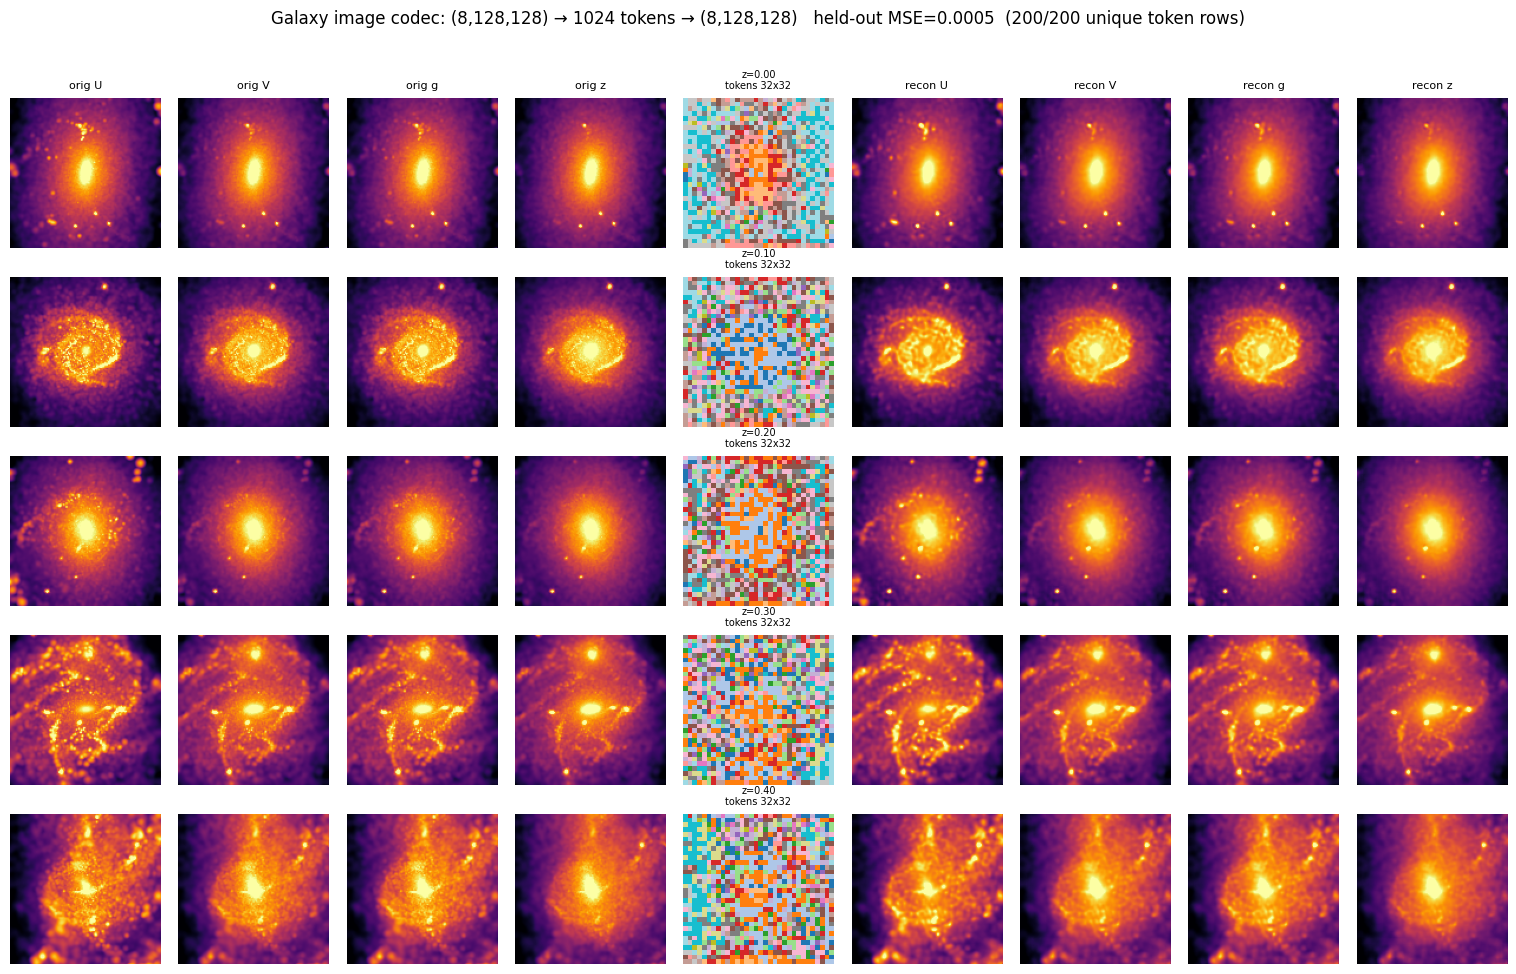

In [16]:
def stretch(im):
    lo, hi = np.percentile(im, 1), np.percentile(im, 99)
    return np.clip((im - lo) / max(hi - lo, 1e-6), 0, 1)

BAND_NAMES = ["U", "B", "V", "K", "g", "r", "i", "z"]
vsel = reps
imgs = val_ds.star_img[vsel].to(DEVICE)
with torch.no_grad():
    tokens = star_codec.encode(SimGalaxyImage(flux=imgs, bands=SIM_BANDS))   # (n, 1024)
    recon  = star_codec.decode(tokens).flux.cpu()
imgs = imgs.cpu()

show_bands = [0, 2, 4, 7]   # U, V, g, z
ncol = len(show_bands)*2 + 1; n_show = len(vsel)
fig, axes = plt.subplots(n_show, ncol, figsize=(ncol*1.7, n_show*1.9))
for gi in range(n_show):
    for ci, b in enumerate(show_bands):
        axes[gi][ci].imshow(stretch(imgs[gi, b].numpy()), cmap="inferno", origin="lower")
        axes[gi][ci].axis("off")
        if gi == 0: axes[gi][ci].set_title(f"orig {BAND_NAMES[b]}", fontsize=8)
    axt = axes[gi][len(show_bands)]
    axt.imshow(tokens[gi].reshape(32, 32).cpu().numpy(), cmap="tab20"); axt.axis("off")
    axt.set_title(f"z={zred[vsel[gi]]:.2f}\ntokens 32x32", fontsize=7)
    for ci, b in enumerate(show_bands):
        axes[gi][len(show_bands)+1+ci].imshow(stretch(recon[gi, b].numpy()), cmap="inferno", origin="lower")
        axes[gi][len(show_bands)+1+ci].axis("off")
        if gi == 0: axes[gi][len(show_bands)+1+ci].set_title(f"recon {BAND_NAMES[b]}", fontsize=8)
fig.suptitle(f"Galaxy image codec: (8,128,128) → 1024 tokens → (8,128,128)   "
             f"held-out MSE={img_mse:.4f}  ({img_uniq}/{len(idx)} unique token rows)", y=1.02)
fig.tight_layout(); plt.show()

---
---

## Putting it together — a token dictionary

After each modality has its own trained codec, we can turn a galaxy into a collection of token sequences. The transformer in Tutorial 2 takes these tokens as a **dictionary of integer tensors**, with one entry per modality and the same batch axis across all entries. Below we tokenize a held-out batch using the trained codecs, just as `sim.train_codecs.tokenize_dataset` does for the full dataset before transformer training. The final dict contains tokens for all **12 modalities**: the galaxy image, SFH, gas and dark-matter profiles, and the 8 scalar properties.


In [17]:
# Tokenize a small held-out batch with the trained codecs.
N_TOK = min(N_TOK, len(val_ds))

@torch.no_grad()
def encode_batched(codec, x, make_mod, bs=16):
    """Encode a tensor in mini-batches to avoid GPU memory issues."""
    chunks = []
    for i in range(0, len(x), bs):
        xb = x[i:i+bs].to(DEVICE)
        chunks.append(codec.encode(make_mod(xb)).cpu())
    return torch.cat(chunks, dim=0)

tokens = {
    "tok_sim_galaxy_image": encode_batched(star_codec,
        val_ds.star_img[:N_TOK],
        lambda xb: SimGalaxyImage(flux=xb, bands=SIM_BANDS),
    ),
    "tok_sim_sfh": sfh_codec.encode(
        SimSFH(value=val_ds.sfh[:N_TOK].to(DEVICE))
    ).cpu(),
    "tok_sim_gas_profile": gas_codec.encode(
        SimGasProfile(value=val_ds.gas_prof[:N_TOK].to(DEVICE))
    ).cpu(),
    "tok_sim_dm_profile": dm_codec.encode(
        SimDMProfile(value=val_ds.dm_prof[:N_TOK].to(DEVICE))
    ).cpu(),
}

# Add the 8 scalar modalities.
for name, (_, Mod, attr, _) in scalar_specs.items():
    x = getattr(val_ds, attr)[:N_TOK].unsqueeze(-1).to(DEVICE)
    tokens[f"tok_{name}"] = scalar_codecs[name].encode(Mod(value=x)).cpu()

# Inspect the token dictionary.
print(f"{'modality':24s} {'shape':>14s} {'max token + 1':>13s}")
for k, v in tokens.items():
    print(f"{k:24s} {str(tuple(v.shape)):>14s} {int(v.max()) + 1:>13d}")

# Save this small demo token file.
out_path = os.path.join(SAVE_DIR, "tokens_demo.pt")
torch.save(tokens, out_path)

n_tokens_per_galaxy = sum(v.shape[1] for v in tokens.values())
print(f"\nsaved -> {out_path}")
print(f"{n_tokens_per_galaxy} tokens per galaxy")

modality                          shape max token + 1
tok_sim_galaxy_image         (64, 1024)           625
tok_sim_sfh                     (64, 6)          1002
tok_sim_gas_profile             (64, 5)          1022
tok_sim_dm_profile              (64, 5)           974
tok_sim_sfr                     (64, 1)          1011
tok_sim_mstar                   (64, 1)          1006
tok_sim_mhalo                   (64, 1)          1007
tok_sim_r200                    (64, 1)          1011
tok_sim_mbh                     (64, 1)          1005
tok_sim_egyRM                   (64, 1)          1007
tok_sim_RMpow                   (64, 1)          1022
tok_sim_redshift                (64, 1)             1

saved -> checkpoints/tokens_demo.pt
1048 tokens per galaxy


## Summary

In this tutorial, we trained one codec per modality so that every galaxy can be represented as a **dictionary of discrete token sequences**. The modalities differ in how much information they carry, so they use different codecs and different numbers of tokens:

| modality                   | # of tokens           | vocabulary size     | codec / quantizer        |
| -------------------------- | --------------------: | ------------------: | ------------------------ |
| `tok_sim_galaxy_image`     |      1024 `(32 × 32)` |                 625 | MagVit-style VQ-AE + FSQ |
| `tok_sim_sfh`              |                     6 |                1024 | ConvNeXt VQ-AE + LFQ     |
| `tok_sim_gas_profile`      |                     5 |                1024 | ConvNeXt VQ-AE + LFQ     |
| `tok_sim_dm_profile`       |                     5 |                1024 | ConvNeXt VQ-AE + LFQ     |
| `tok_sim_*` scalars `(×8)` |                1 each |                1024 | quantile / reservoir-CDF |

The scalar modalities, `sfr`, `mstar`, `mhalo`, `r200`, `mbh`, `egyrm`, `rmpow`, and `redshift`, are mapped to **one ordinal token each** using a quantile quantizer. This is near-lossless for scalar values, calibrated on the training split, and does not require GPU training.

The 1-D modalities, including the SFH and the gas / dark-matter radial profiles, are compressed with small neural codecs: a `ConvNeXt-style VQ autoencoder` followed by LFQ. These produce short token sequences: 6 tokens for the SFH and 5 tokens for each radial profile.

The 2-D galaxy image carries the most information, so it uses the heaviest codec: a `MagVit-style convolutional VQ autoencoder` with FSQ. The face-on galaxy image is compressed into a `32 × 32` grid, giving 1024 image tokens per galaxy.

Each neural codec was trained on the full multi-redshift training set by running with `GAL4M_TRAIN=1` on a GPU. During training, we selected the checkpoint with the lowest held-out validation MSE and saved it under `checkpoints/codecs/<modality>/`. The reconstructions shown above were produced by loading those saved checkpoints and decoding the held-out 500-galaxy validation set. The star-image normalization uses one fixed constant, stored in `img_norm.json`, shared consistently across training, validation, and tokenization.

To retrain all codecs from scratch, run:

```bash
python -m sim.train_codecs
```

This trains over all five snapshots, performs best-by-validation checkpoint selection, uses a scalar vocabulary size of 1024, and applies the gas / dark-matter profile `calibrate()` standardization. On one V100 GPU, the full training run takes about 3 hours.

Next, we will train the multimodal transformer on these token dictionaries in **`tutorial-2-transformer.ipynb`**.
